# Segmentacija slika pomoću spektralnog klasterovanja

Cilj ove sveske je primena spektralnog klasterovanja (implementiranog u `src/spectral.py`) na problem segmentacije slika.

Pošto direktna primena algoritma na sve piksele slike nije računski izvodljiva (matrica sličnosti bi imala $n^2 \times n^2$ elemenata za sliku sa $n^2$ piksela), slika se prvo deli na **superpiksele** pomoću SLIC algoritma, a graf se zatim gradi nad njima umesto nad pojedinačnim pikselima.

## Pregled parametara

Pre nego što pređemo na analizu, ovde je kratak pregled svih parametara koji se koriste u 
pipeline-u i koji će biti sistematski testirani u narednim eksperimentima.

### SLIC (superpikseli)

| Parametar | Opis |
|---|---|
| `n_segments` | Željeni broj superpiksela na koje se slika deli. Veće vrednosti daju sitnije, brojnije superpiksele — bitno za osetljivost na male objekte na slici. |
| `compactness` | Kontroliše oblik superpiksela: veće vrednosti daju kompaktnije, pravilnije regione, manje vrednosti čine da superpikseli više prate prirodne ivice boja. |

### Karakteristike superpiksela (`compute_superpixel_features`)

Za svaki superpiksel se računaju dve karakteristike:
- **Boja** — prosečna RGB vrednost piksela unutar superpiksela
- **Pozicija** — centroid (prosečna row/col koordinata) superpiksela

### Matrica sličnosti (`build_image_similarity_matrix`)

| Parametar | Opis |
|---|---|
| `sigma_color` | Kontroliše koliko strogo se poštuje sličnost u boji — manje vrednosti favorizuju razlikovanje i suptilnih razlika u boji, veće vrednosti čine da sličnost u boji ima manji uticaj. |
| `position_ratio` | Relativna prostorna skala. Konkretna vrednost `sigma_position` računa se kao `position_ratio · sqrt(H² + W²)`, tj. kao deo dijagonale slike. Manje vrednosti strože favorizuju prostorno bliske superpiksele, dok veće vrednosti smanjuju uticaj prostorne udaljenosti. |

### Spektralno klasterovanje (`spectral_clustering_from_similarity`)

| Parametar | Opis |
|---|---|
| `k` | Broj klastera (segmenata) na koje se slika deli. Direktno određuje granularnost segmentacije. |
| `normalized` | Da li se koristi normalizovani Laplasijan ($L_{sym}$) ili nenormalizovani ($L$). U svim eksperimentima koristi se `normalized=True`; u toj varijanti se redovi matrice $U$ dodatno normalizuju na jediničnu normu pre K-means koraka, u skladu sa Ng-Jordan-Weiss algoritmom. |

U narednim eksperimentima, jedan od ovih parametara se sistematski menja dok su ostali fiksirani na razumne podrazumevane vrednosti (npr. `n_segments=200`, `sigma_color=20`, `position_ratio=0.1`, `compactness=10`), kako bi se izolovao uticaj svakog pojedinačnog parametra na rezultat segmentacije. Ovako `sigma_position` više nije fiksna vrednost u pikselima, već se automatski prilagođava veličini svake slike.

## Pregled skupa podataka

Pre analize, dajemo kratak pregled slika korišćenih u ovoj svesci — korišćeno je pet slika, namerno 
odabranih da pokriju različite tipove vizuelne strukture (jednostavan kontrast, repetitivna 
tekstura, više objekata različite veličine, objekat sličan pozadini po boji).

In [14]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.segmentation import slic, mark_boundaries

from image_utils import (
    compute_superpixel_features,
    build_image_similarity_matrix
)
from spectral import spectral_clustering_from_similarity
from visualization import run_segmentation_grid, analyze_image

Ukupan broj slika: 5

apple.jfif: 2047x2048 px, 3 kanala
balloons.jfif: 750x1334 px, 3 kanala
fields.jfif: 1857x2048 px, 3 kanala
parrot.jfif: 2048x1537 px, 3 kanala
yellow_lilly.jpg: 4032x3024 px, 3 kanala


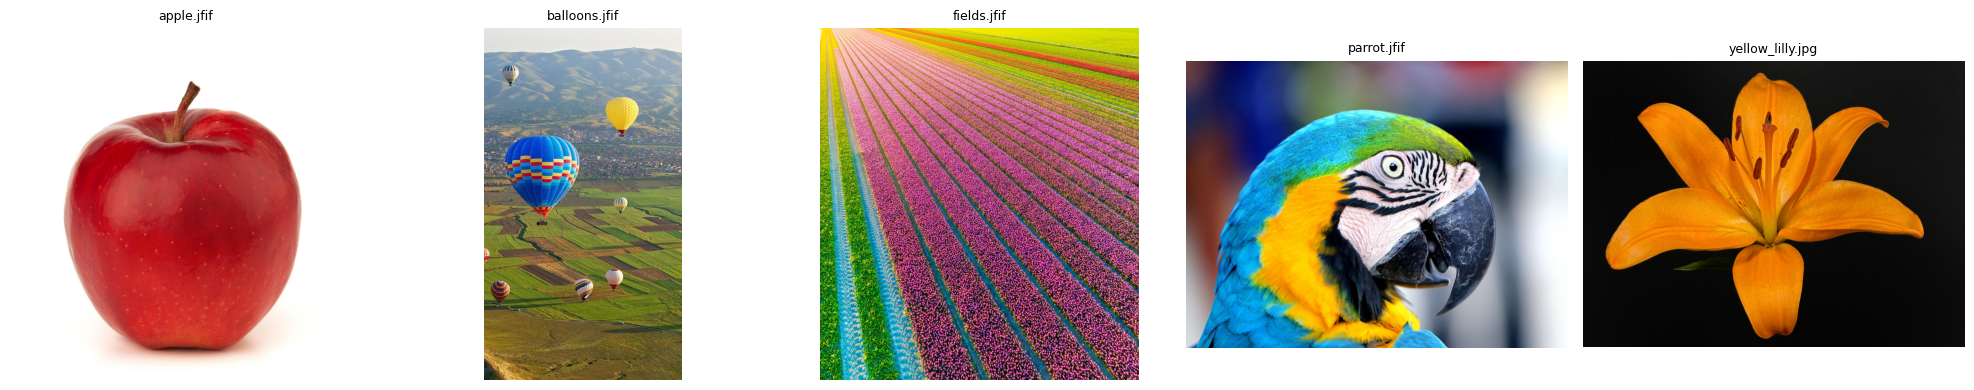

In [15]:
import os

image_dir = '../data/sample_images'
image_files = sorted(f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.jfif', '.png')))

print(f"Ukupan broj slika: {len(image_files)}\n")

fig, axes = plt.subplots(1, len(image_files), figsize=(4 * len(image_files), 4))

for ax, fname in zip(axes, image_files):
    img = io.imread(os.path.join(image_dir, fname))
    print(f"{fname}: {img.shape[1]}x{img.shape[0]} px, {img.shape[2]} kanala")
    ax.imshow(img)
    ax.set_title(fname, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

**Napomena:** Pošto zadatak nije klasifikacija sa unapred definisanim klasama, tradicionalni pojam 
balansiranosti ovde se ne primenjuje. Umesto toga, raznovrsnost skupa se ogleda u razlici u vizuelnoj strukturi slika (kontrast, tekstura, broj i veličina objekata) — svaka slika je odabrana da testira drugačiji aspekt ponašanja algoritma, kao što je detaljno pokazano u analizama 
koje slede.

## 1. Analiza slika

Kao prvi test primer koristimo fotografiju cveta na uniformnoj crnoj pozadini — jednostavna, kontrastna struktura, pogodna za detaljnu proveru celog pipeline-a. Ista logika primenjuje se na četiri dodatne slike, radi provere da pristup konzistentno radi na različitim vizuelnim strukturama (pejzaž, objekat na stolu, izolovan predmet, ptica sa teksturiranim perjem).

### 1.1 Cvet na uniformnoj pozadini

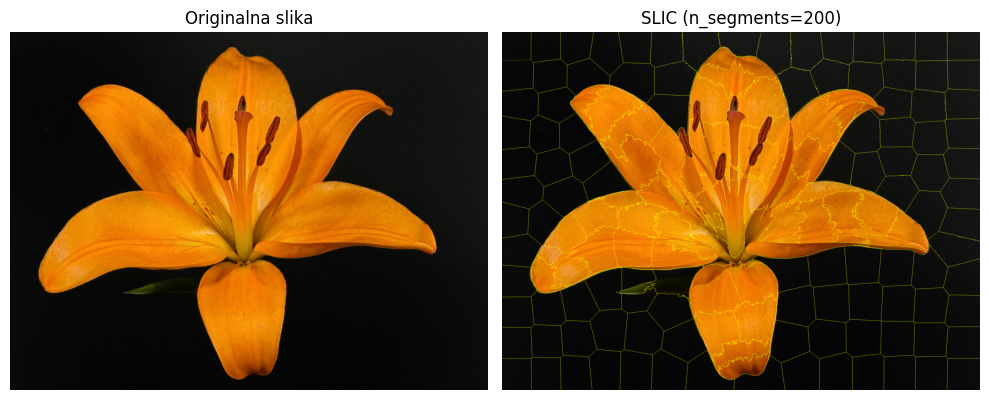

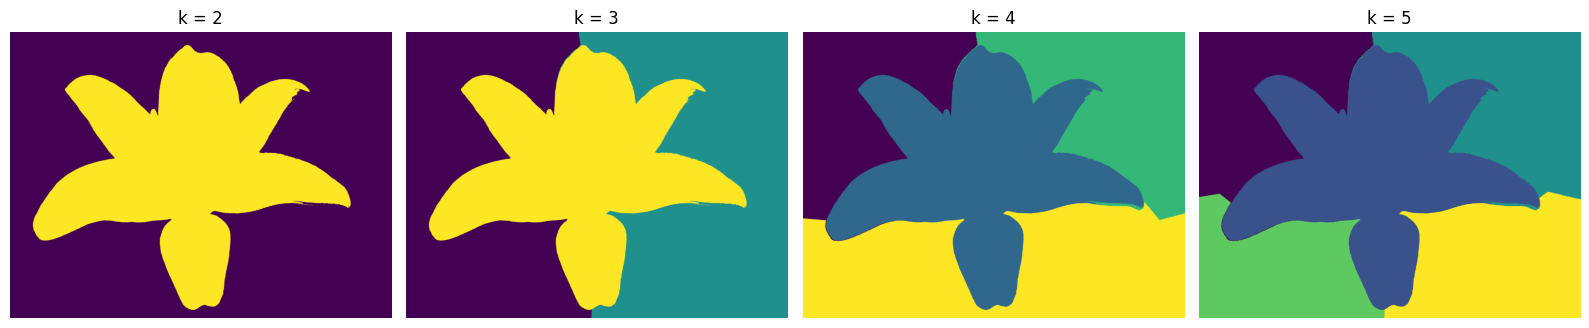

In [16]:
image, segments, colors, positions = analyze_image('../data/sample_images/yellow_lilly.jpg')

**Zapažanje o k-gridu:** Sa porastom $k$, cvet uglavnom ostaje izdvojen kao jedan stabilan region, dok se dodatni klasteri pre svega koriste za finiju podelu pozadine. Za ovu sliku vrednosti $k=2$ i $k=3$  daju najjednostavniju i najinterpretabilniju segmentaciju.

### 1.1.1 Uticaj prostornog parametra ($\sigma_{position}$)

Pored broja klastera, ispitujemo i uticaj $\sigma_{position}$, koji kontroliše koliko strogo se poštuje prostorna blizina prilikom određivanja sličnosti dva superpiksela. Testiramo uz fiksiran $k=4$.

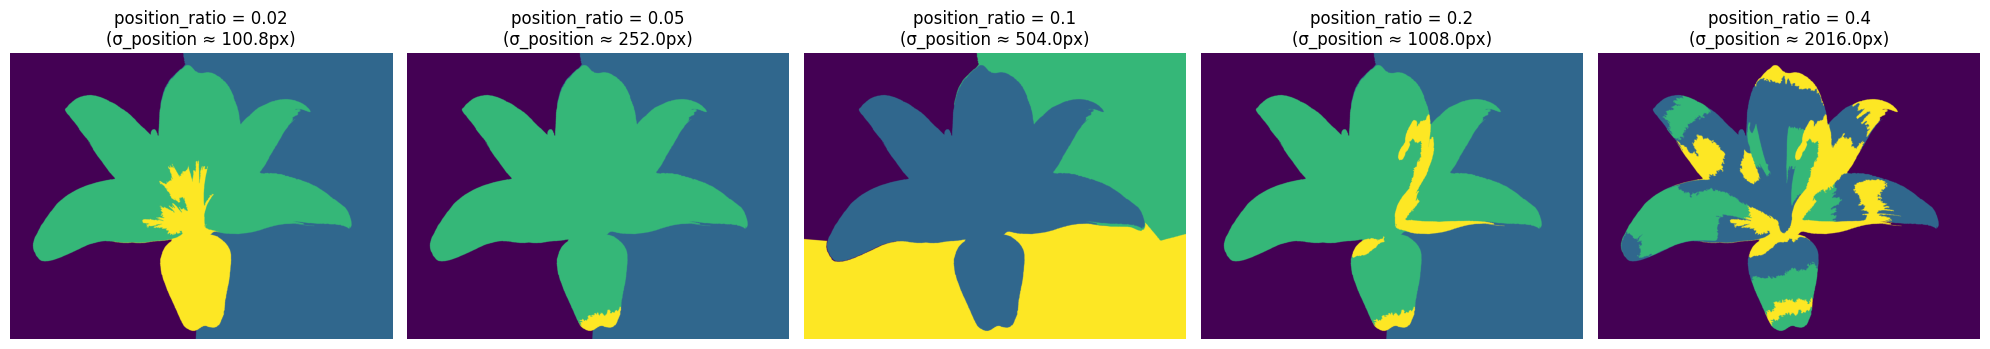

In [17]:
run_segmentation_grid(segments, colors, positions,
                       param_name='position_ratio', param_values=[0.02,0.05,0.1,0.2,0.4], fixed_k=4)

**Zapažanje:** Za manje vrednosti position_ratio, odnosno $\sigma_{position}$, prostorna udaljenost ima veći uticaj na sličnost superpiksela, pa se prostorno udaljeni regioni mogu razdvojiti čak i kada imaju slične boje. Sa porastom position_ratio, uticaj prostorne udaljenosti slabi, pa boja postaje dominantnija pri formiranju klastera. Na ovoj slici srednje vrednosti parametra daju kompaktnije regione, dok velika vrednost (position_ratio = 0.4) dovodi do izraženije fragmentacije segmentacije.

### 1.2 Fields

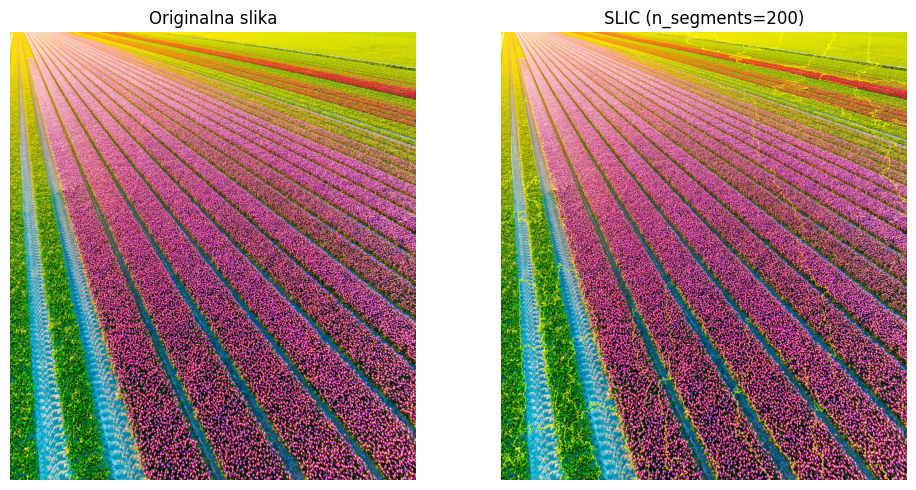

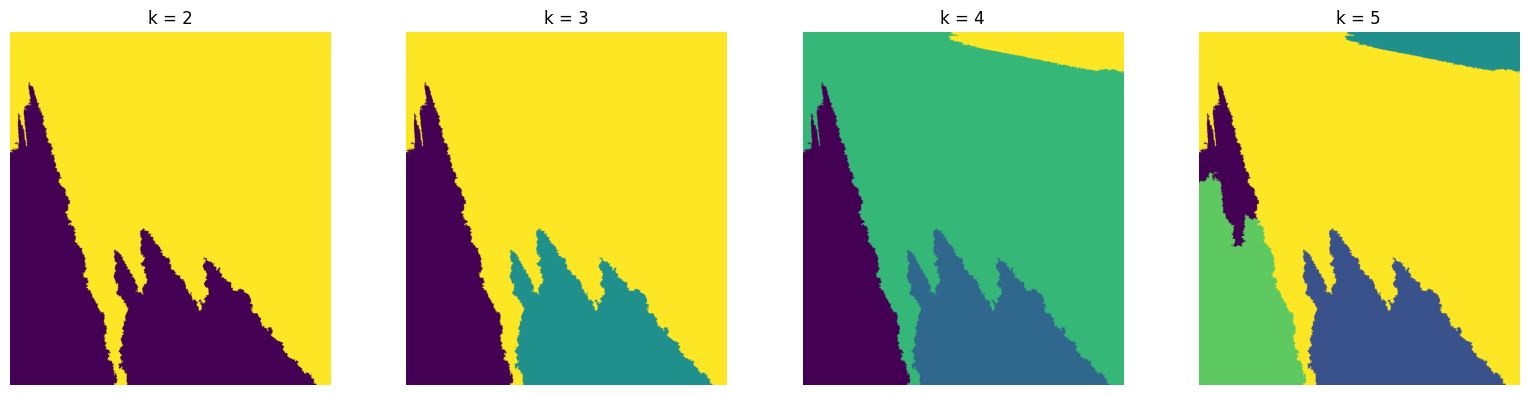

In [18]:
image_2, segments_2, colors_2, positions_2 = analyze_image('../data/sample_images/fields.jfif')

### 1.2.1 Uticaj prostornog parametra ($\sigma_{position}$)

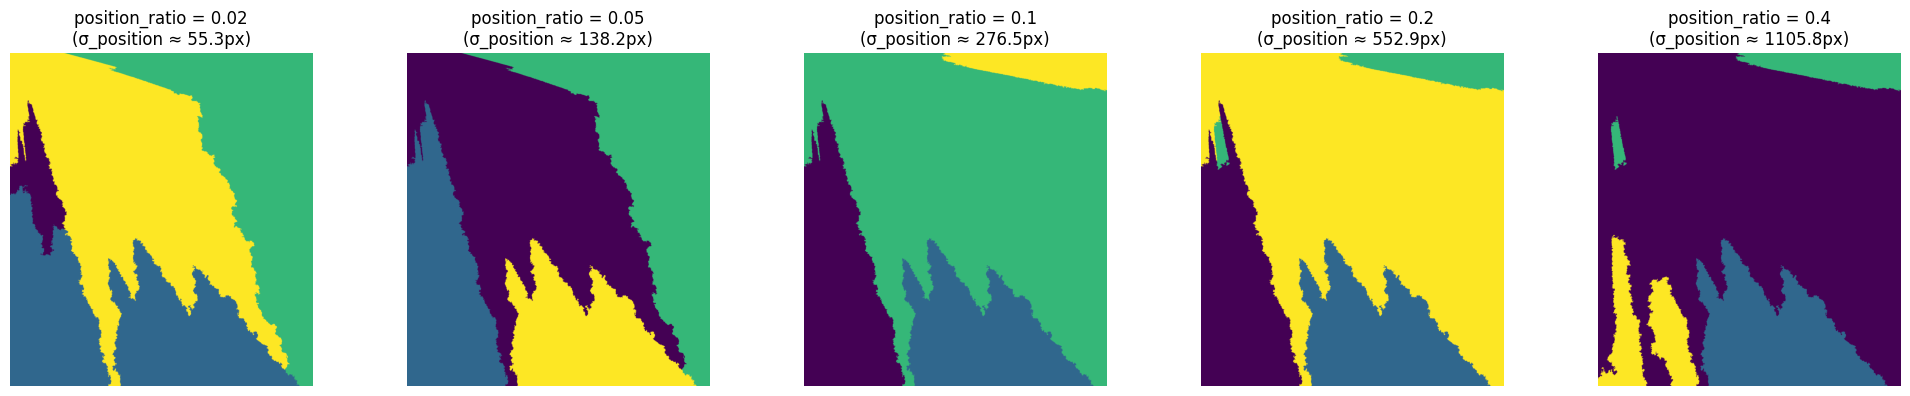

In [19]:
run_segmentation_grid(segments_2, colors_2, positions_2,
                       param_name='position_ratio', param_values=[0.02,0.05,0.1,0.2,0.4], fixed_k=4)

### 1.2.1 Uticaj parametra boje ($\sigma_{color}$)

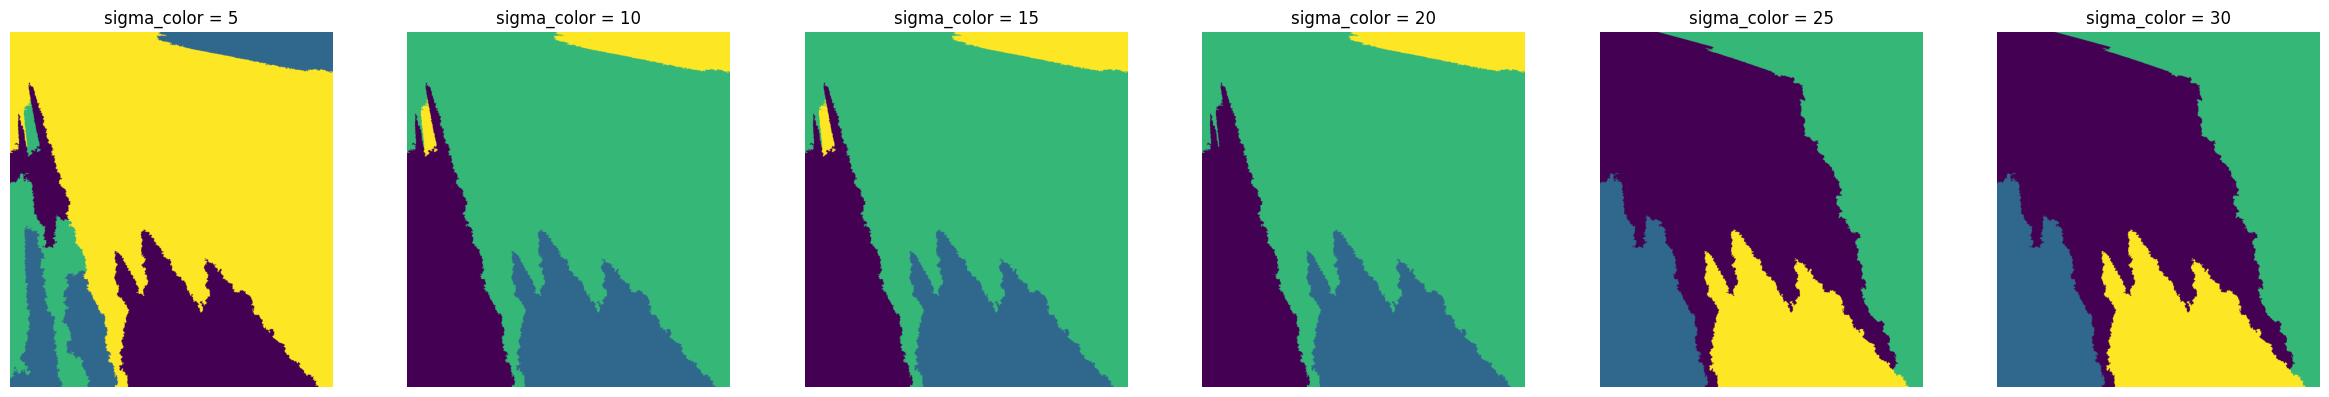

In [20]:
run_segmentation_grid(segments_2, colors_2, positions_2,
                       param_name='sigma_color', param_values=[5,10,15,20,25,30], fixed_k=4)

**Zapažanje:** Uticaj ova dva parametra se razlikuje. Pri malim vrednostima $\sigma_{color}$ algoritam je veoma osetljiv na razlike u boji, pa uspeva da izdvoji i neke uže strukture koje odgovaraju pojedinačnim redovima cveća. Međutim, takva segmentacija nije stabilna i redovi nisu konzistentno izdvojeni. Sa povećanjem $\sigma_{color}$ manje razlike u boji gube značaj i algoritam prelazi na izdvajanje većih i homogenijih regiona. Kod position_ratio male vrednosti snažno naglašavaju prostornu blizinu, dok srednje vrednosti daju kompaktniju podelu većih oblasti; pri velikim vrednostima uticaj položaja slabi i segmentacija se ponovo značajno menja. Rezultati pokazuju da kombinacija boje i prostorne pozicije dobro izdvaja veće regione, ali teže razlikuje ponavljajuće strukture slične boje.

### 1.3 Apple

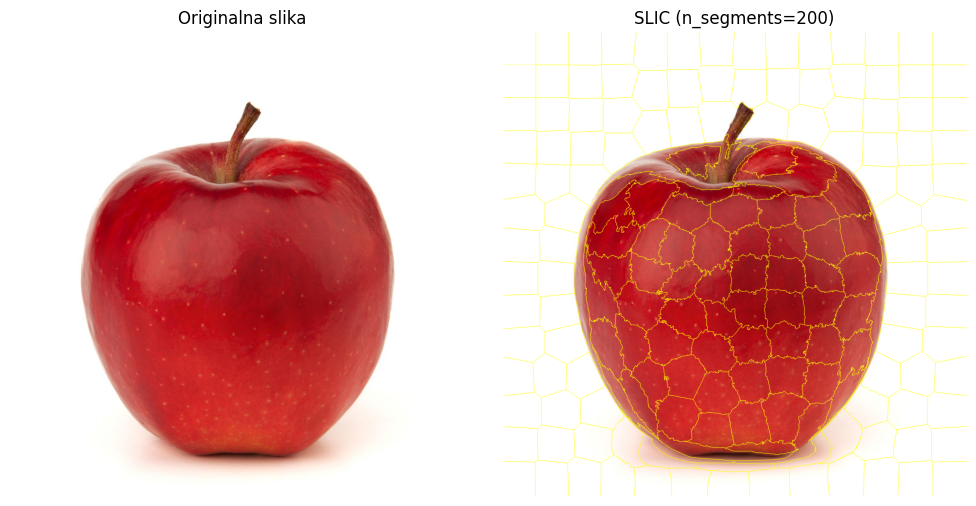

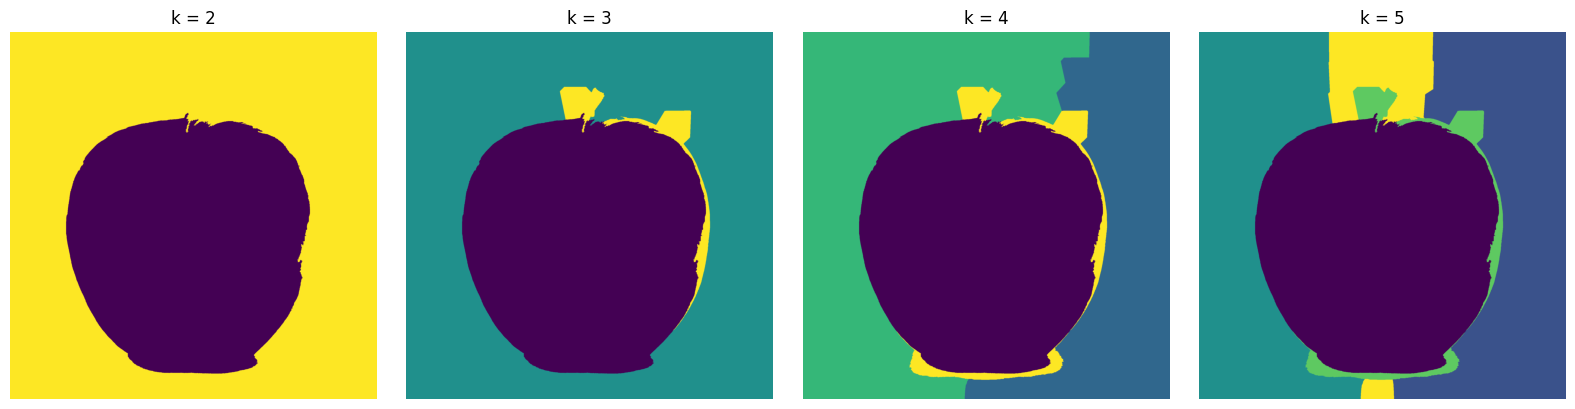

In [21]:
_ = analyze_image('../data/sample_images/apple.jfif')

**Zapažanje:** Za razliku od slike sa poljima, ovde postoji jasan, dominantan kontrast u boji između jabuke i pozadine, pa jabuka ostaje stabilno izdvojena kao jedan kompaktan segment za sve testirane vrednosti $k$. Za $k=2$ dobija se najjednostavnija podela na jabuku i pozadinu, dok se sa povećanjem $k$ dodatni klasteri uglavnom koriste za podelu pozadine i izdvajanje manjih detalja oko jabuke. Ovaj primer pokazuje da izražen kontrast u boji omogućava stabilno prepoznavanje dominantnog objekta, dok povećanje broja klastera dovodi do finije segmentacije ostalih delova slike.

### 1.4 Balloon

### 1.4.1 Uticaj parametra $k$

U narednom primeru, testiramo više različitih vrednosti parametra k, kako bismo videli da li se segmentacija popravlja njegovim porastom.

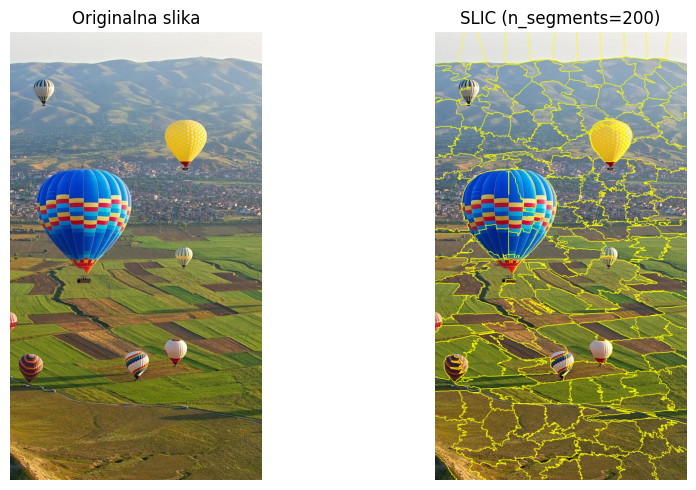

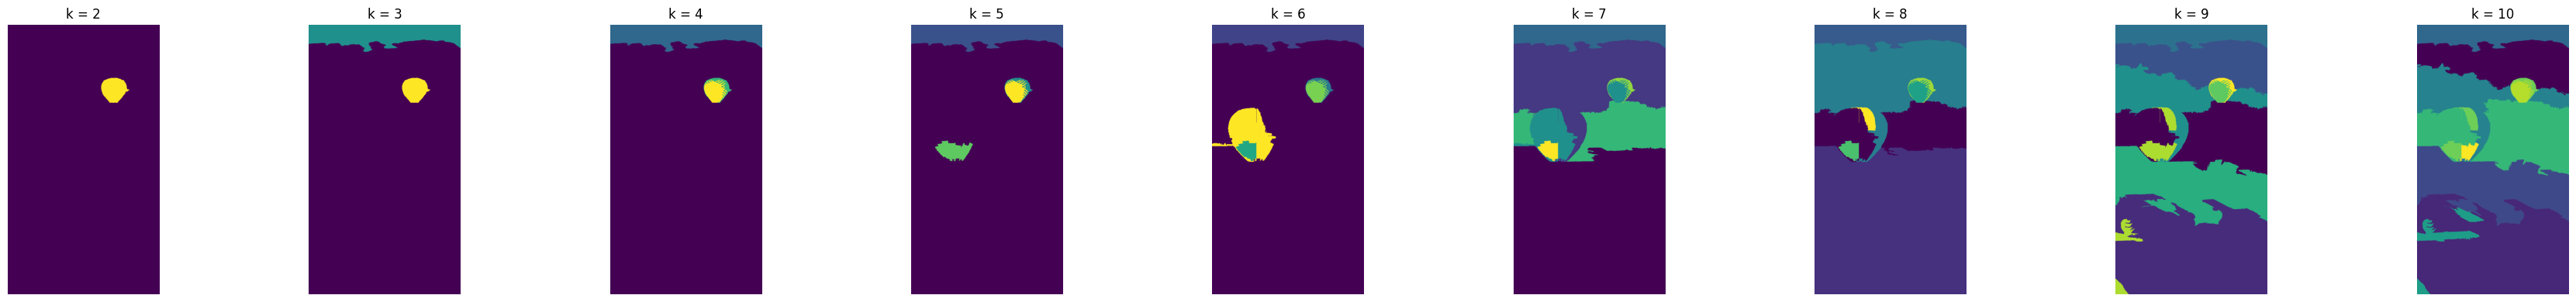

In [22]:
_ = analyze_image('../data/sample_images/balloons.jfif', n_segments=200, k_values=[2, 3, 4, 5, 6, 7, 8, 9, 10])

### 1.4.2 Uticaj parametra $n\_segments$

Takođe ćemo testirati i različite vrednosti parametra n_segments, koji utiče na granularnost superpiksela na slici.

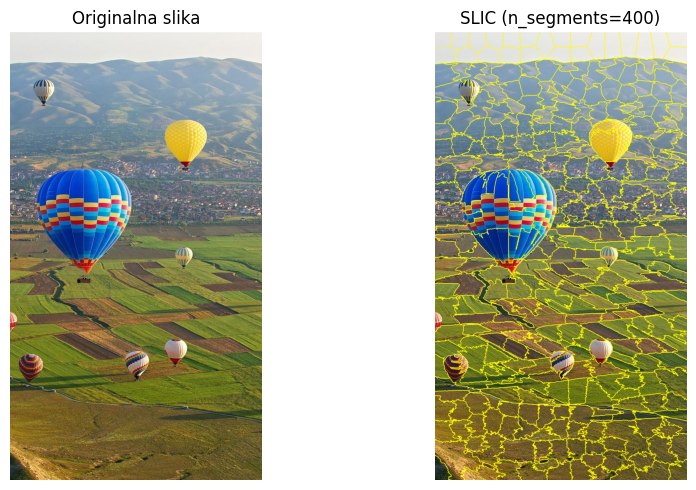

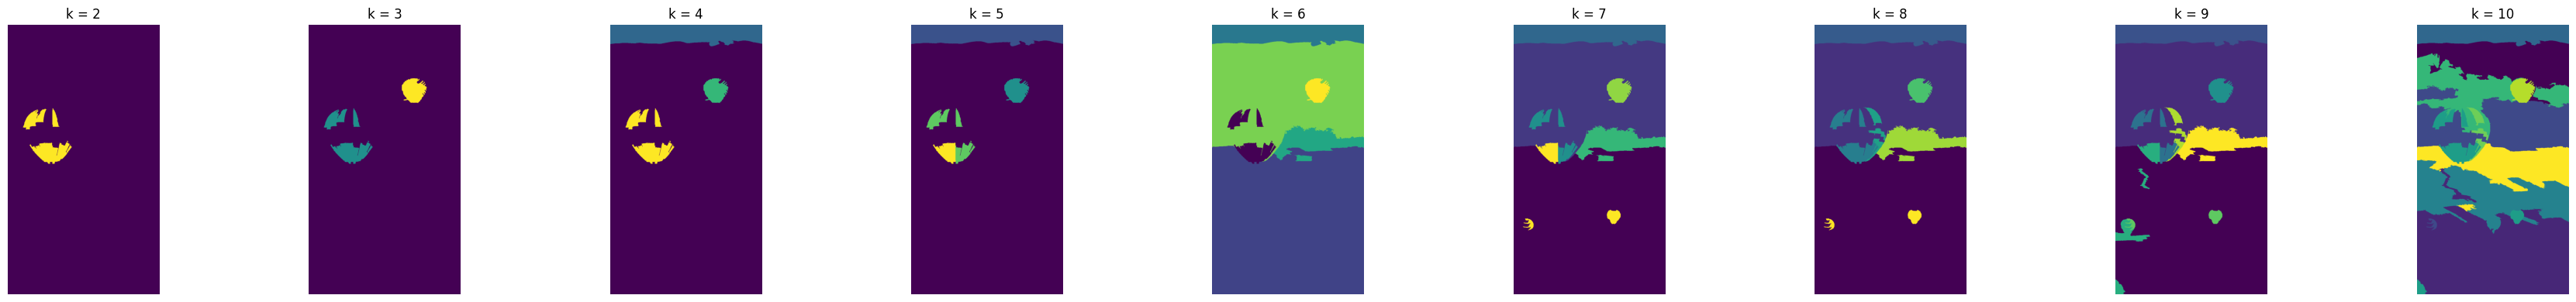

In [23]:
_ = analyze_image('../data/sample_images/balloons.jfif', n_segments=400, k_values=[2, 3, 4, 5, 6, 7, 8, 9, 10])

**Zapažanje:** Sa $n\_segments=200$, pri malim vrednostima $k$ (2 i 3) algoritam izdvaja samo najizraženiji, žuti balon, dok se sa povećanjem broja klastera postepeno izdvajaju i manji objekti u pozadini. Veliki plavi balon se kao zaseban region jasnije izdvaja tek pri većim vrednostima $k$, što se može objasniti njegovim manjim kontrastom u odnosu na okolinu. Sličan obrazac se uočava i za $n\_segments=400$. Veći broj superpiksela daje finiju reprezentaciju slike i omogućava brže izdvajanje najizraženijeg, žutog balona, ali ne rešava problem objekata koji su po boji slični pozadini. Rezultati pokazuju da na uspešnost segmentacije utiču, kako veličina i prostorna reprezentacija objekta, tako i njegov kontrast u odnosu na okolinu. Objekti sa izraženijom razlikom u boji izdvajaju se već pri manjim vrednostima $k$, dok je za objekte koji su sličniji pozadini potrebna detaljnija podela na klastere.

### 1.5 Parrot

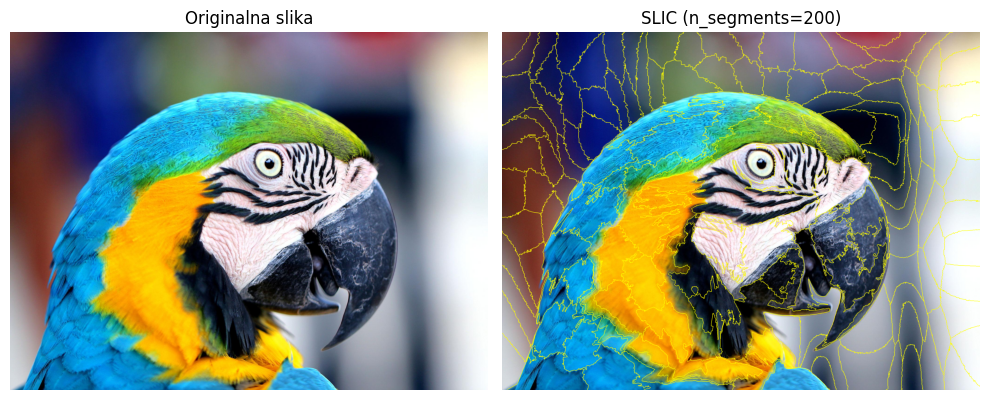

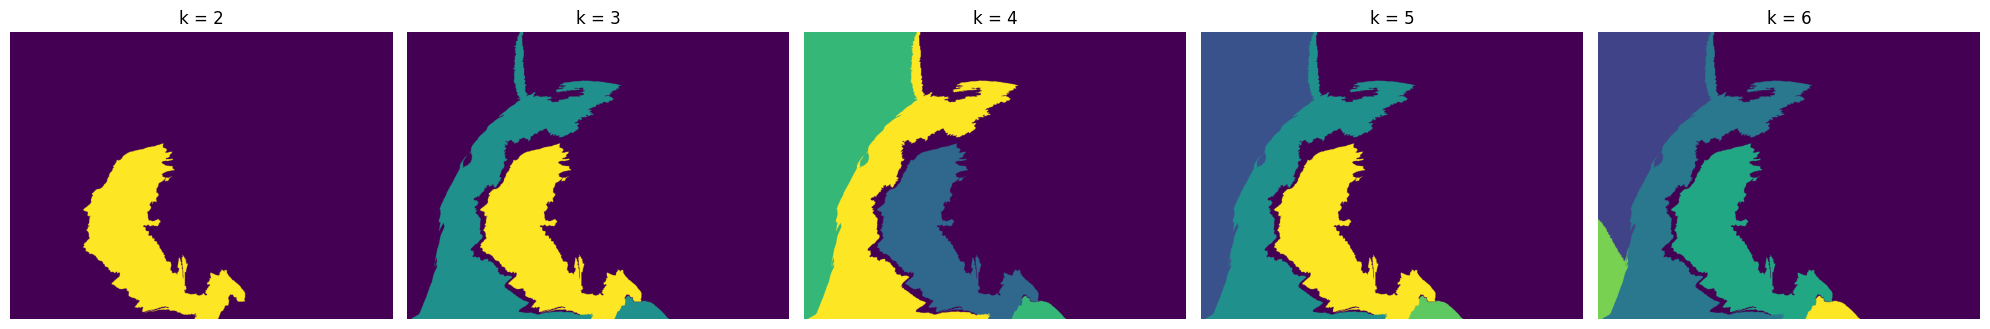

In [24]:
image_4, segments_4, colors_4, positions_4 = analyze_image('../data/sample_images/parrot.jfif',  k_values=[2, 3, 4, 5, 6])

### 1.5.1 Uticaj parametra pozicije ($\sigma_{position}$)

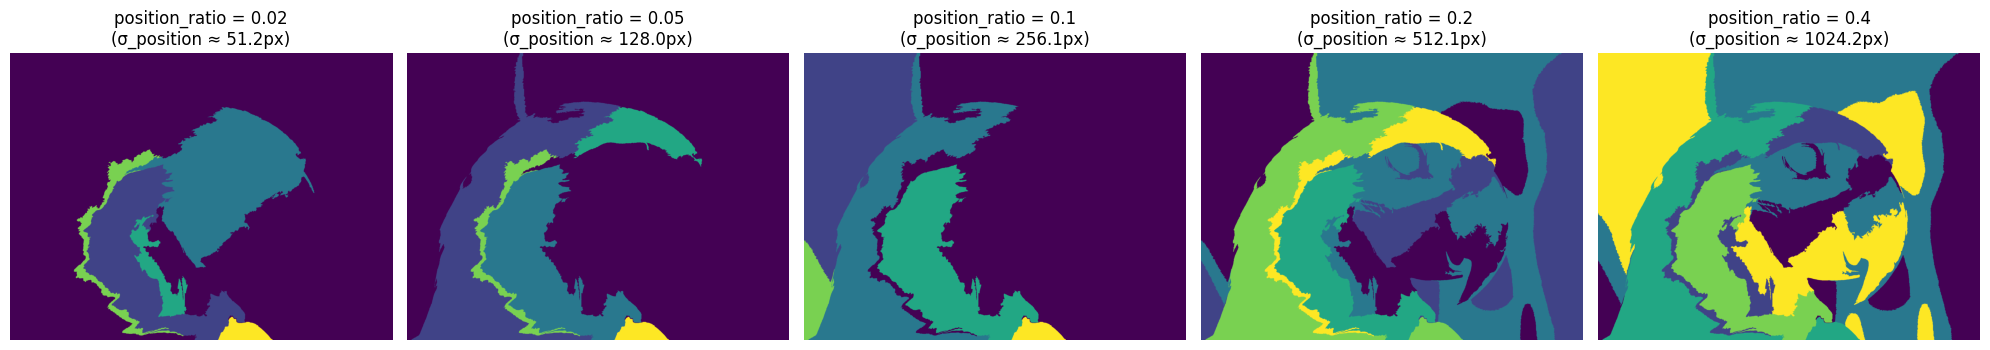

In [25]:
run_segmentation_grid(segments_4, colors_4, positions_4,
                       param_name='position_ratio', param_values=[0.02,0.05,0.1,0.2,0.4], fixed_k=6)

### 1.5.2 Uticaj parametra boje ($\sigma_{color}$)

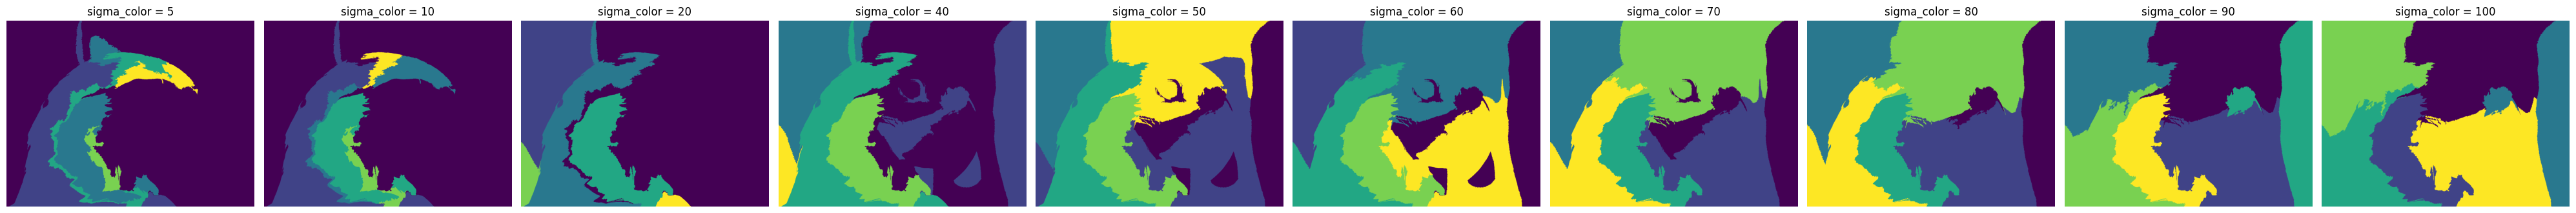

In [26]:
run_segmentation_grid(segments_4, colors_4, positions_4,
                       param_name='sigma_color', param_values=[5,10,20,40,50,60,70,80,90,100], fixed_k=6)

**Zapažanje:** Variranje broja klastera $k$, kao i parametara position_ratio i $\sigma_{color}$, značajno utiče na segmentaciju, ali nijedna od testiranih kombinacija ne uspeva da potpuno i stabilno izdvoji siluetu papagaja. Najpribližniji rezultat dobija se za position_ratio = 0.4, kada je veći deo strukture ptice prepoznatljiv. Veća vrednost ovog parametra odgovara većem $\sigma_{position}$, čime se smanjuje uticaj prostorne udaljenosti na sličnost i omogućava da prostorno udaljeniji delovi slične boje lakše pripadnu istom klasteru. Ipak, delovi perja se i dalje spajaju sa pozadinom ili pripadaju različitim klasterima. Razlog je verovatno sličnost prosečne boje plavog perja i zamućene plavičaste pozadine, dok karakteristike poput teksture i oštrine nisu deo trenutne reprezentacije superpiksela. Ovaj primer zato pokazuje ograničenje pristupa zasnovanog samo na boji i prostornoj poziciji.

### Zaključak

- Kombinacija SLIC superpiksela i spektralnog klasterovanja omogućava segmentaciju slika u razumnom vremenu, zaobilazeći problem velike matrice sličnosti koja bi nastala radom direktno nad pojedinačnim pikselima.

- Broj klastera $k$ određuje granularnost segmentacije — manje vrednosti uglavnom daju grublju, a veće finiju podelu slike.

- Parametri `position_ratio` (odnosno skalirani $\sigma_{position}$) i $\sigma_{color}$ određuju uticaj prostorne udaljenosti i razlike u boji na sličnost superpiksela. Manje vrednosti postavljaju stroži kriterijum sličnosti, dok veće vrednosti ublažavaju uticaj odgovarajuće karakteristike. Njihov izbor može značajno promeniti segmentaciju, posebno kod slika sa vizuelno sličnim, ali prostorno razdvojenim regionima.

- Testiranje na pet različitih slika pokazuje da pristup najbolje radi kada postoji jasan i globalno dosledan kontrast u boji između objekta i pozadine, kao kod cveta i jabuke, gde dominantni objekat ostaje stabilno izdvojen i pri promeni parametara. Pristup je zahtevniji u sledećim situacijama:

  1. **Repetitivna tekstura bez jasne globalne razlike u boji** (polja cveća) — algoritam uspeva da izdvoji pojedine lokalne strukture, ali ne i da konzistentno prepozna sve redove cveća kao zasebne regione.

  2. **Više objekata različite prostorne veličine** (baloni) — veći broj superpiksela daje finiju reprezentaciju, ali ne garantuje bolju segmentaciju; manji objekti i objekti slični pozadini zahtevaju odgovarajući izbor broja klastera.

  3. **Slična boja objekta i pozadine** (papagaj) — promena parametara utiče na rezultat, pri čemu veći `position_ratio` daje približniju segmentaciju siluete, ali nijedna testirana kombinacija ne izdvaja papagaja potpuno i stabilno. To ukazuje na ograničenje reprezentacije zasnovane samo na prosečnoj boji i poziciji, jer ne uključuje informacije poput teksture i oštrine.

**Dalji rad:** Kvantitativna evaluacija na skupu BSDS500, koji sadrži više ljudskih ground-truth segmentacija po slici, kao i poređenje sa baseline K-means metodom bez grafovske strukture.